### Step 1: Import crucial libraries. ###

In [3]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

In [10]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization

In [11]:
#-- Load data file. --#
try:
    df = pd.read_csv('../Processed/efficiency_stations.csv')
    print(f"✅ Successfully loaded dataset.")
except:
    print(f"❌ Failed to load dataset. Please check the file path and ensure the dataset is available.")

✅ Successfully loaded dataset.


### Step 2: Exploratoty Data Analysis (EDA) and Data Cleaning. ###

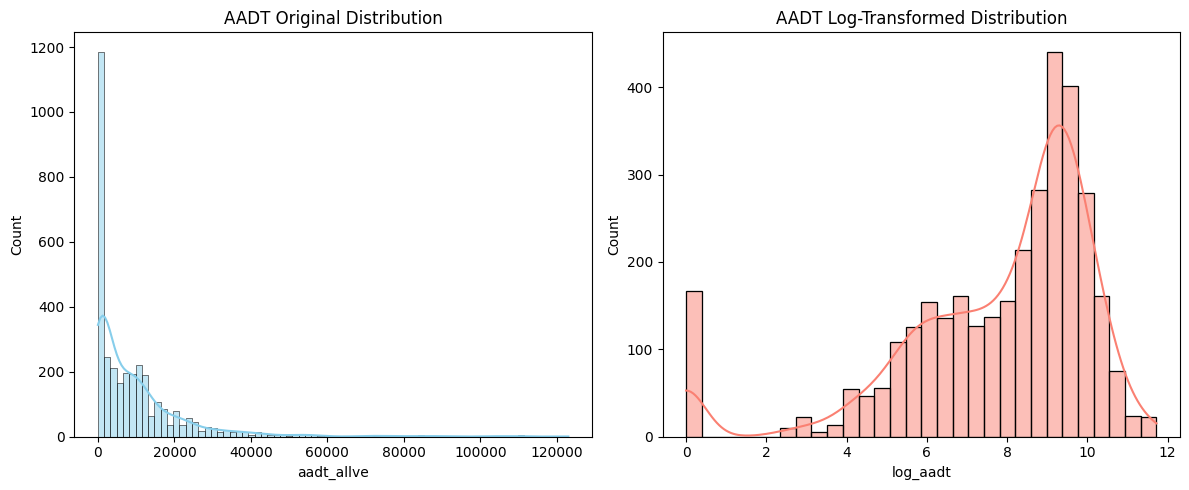

Saved: ../Figures//aadt_distribution.png


In [12]:
#-- Folder save. --#
folder_saved = '../Figures/'

#-- Select revelant features and target variable. --#
feature_cols = ['x', 'y', 'last_year', 'efficiency_index']
target_col = 'aadt_allve'

#-- Data cleaning. --#
df_clean = df.dropna(subset=feature_cols + [target_col]).copy()

#-- Target Variable Transformation. --#
df_clean['log_aadt'] = np.log1p(df_clean[target_col])

#-- Visualizing Data Distribution for the Report
plt.figure(figsize=(12, 5))

#-- Subplot 1: Original Distribution. --#
plt.subplot(1, 2, 1)
sns.histplot(df_clean[target_col], kde=True, color='skyblue')
plt.title('AADT Original Distribution')

#-- Subplot 2: Log Distribution. --#
plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_aadt'], kde=True, color='salmon')
plt.title('AADT Log-Transformed Distribution')

plt.tight_layout()
# Save the figure to DFigures folder
plt.savefig(f'{folder_saved}/aadt_distribution.png')
plt.show()
print(f"Saved: {folder_saved}/aadt_distribution.png")


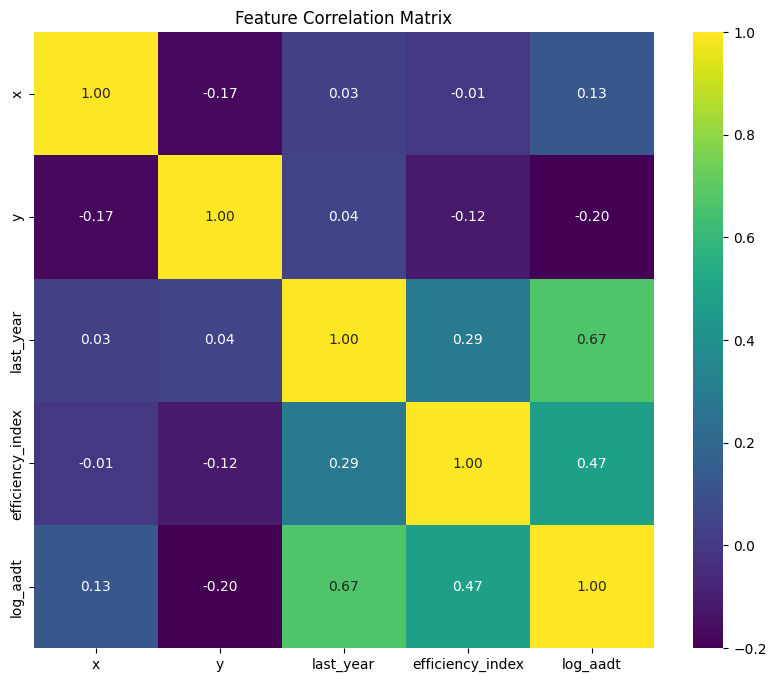

Saved: ../Figures//correlation_heatmap.png

✅ EDA Completed. Cleaned dataset size: 3380


In [13]:
#-- Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[feature_cols + ['log_aadt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Feature Correlation Matrix')

# Save the heatmap to DFigures folder
plt.savefig(f'{folder_saved}/correlation_heatmap.png')
plt.show()
print(f"Saved: {folder_saved}/correlation_heatmap.png")

print(f"\n✅ EDA Completed. Cleaned dataset size: {len(df_clean)}")

### Step 3: Data preparationa nd Sequence Generation ###

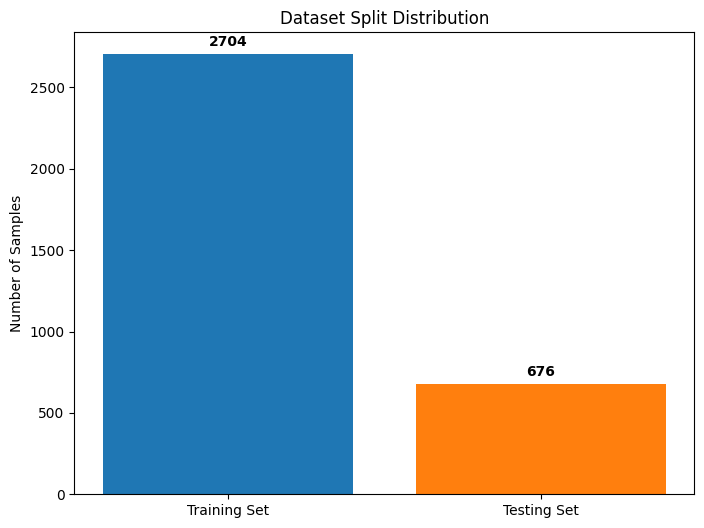

✅ Step 3 Completed.
X_train shape: (2704, 1, 4) (Successfully converted to 3D for BLSTM)
Plot saved to: ../Figures//data_split_distribution.png


In [14]:
#-- Saved folder. --#
saved_folder = '../Figures/'

#-- Feature Selection. --3
#-- In the BLSTM, our team uses coordinates, time, and efficiency as predictors. --#
X_raw = df_clean[['x', 'y', 'last_year', 'efficiency_index']].values
y_raw = df_clean['log_aadt'].values

#-- Data Normalization (Scaling). --#
# Neural Networks like BLSTM perform better when features are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

#-- Reshaping for BLSTM (3D Input). --#
# Format: (Number of Samples, Time Steps, Number of Features)
# Since each record is a single snapshot, Time Steps = 1
X_seq = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y_seq = y_raw

#-- Train-Test Split (80% Train, 20% Test). --#
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    random_state=42
)

#-- Visualization of Data Distribution for the Report. --#
plt.figure(figsize=(8, 6))
sets = ['Training Set', 'Testing Set']
counts = [len(X_train), len(X_test)]
plt.bar(sets, counts, color=['#1f77b4', '#ff7f0e'])
plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')

#-- Adding text labels on top of bars. --#
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontweight='bold')

# Save the plot to the Figures folder
plt.savefig(f'{saved_folder}/data_split_distribution.png')
plt.show()

print(f"✅ Step 3 Completed.")
print(f"X_train shape: {X_train.shape} (Successfully converted to 3D for BLSTM)")
print(f"Plot saved to: {saved_folder}/data_split_distribution.png")



### BLSTM Model and Training ###

In [17]:
saved_folder = '../Figures/'

#-- Define the BLSTM Model. --#
model_blstm = Sequential([
    #-- Layer 1: Bidirectional LSTM with 64 units. --#
    Bidirectional(LSTM(units=64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    BatchNormalization(),
    
    #-- Layer 2: Bidirectional LSTM with 32 units. --#
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    
    #-- Output Layer: Regression for Predicted AADT. --#
    Dense(units=1)
])

#-- Compile the Model. --#
model_blstm.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])

#-- Callbacks for optimal training. --#
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5, verbose=1)
]

#-- Evaluate Training. --#
print("--- Starting BLSTM Training Phase ---")
history_blstm = model_blstm.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

--- Starting BLSTM Training Phase ---
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 5.9588 - mae: 6.4458 - val_loss: 4.7796 - val_mae: 5.2643 - learning_rate: 0.0010
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4717 - mae: 1.9128 - val_loss: 1.7496 - val_mae: 2.2165 - learning_rate: 0.0010
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7284 - mae: 1.1253 - val_loss: 0.8753 - val_mae: 1.3127 - learning_rate: 0.0010
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6521 - mae: 1.0441 - val_loss: 0.6375 - val_mae: 1.0490 - learning_rate: 0.0010
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6218 - mae: 1.0080 - val_loss: 0.5024 - val_mae: 0.8847 - learning_rate: 0.0010
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6223 - mae: 1.0090 - val_loss: 0.4429 - val_mae: 0.7782 - learning_rate: 0.0010
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6073 - mae: 0.9916 - val_loss: 0.4310 - val_mae: 0.76

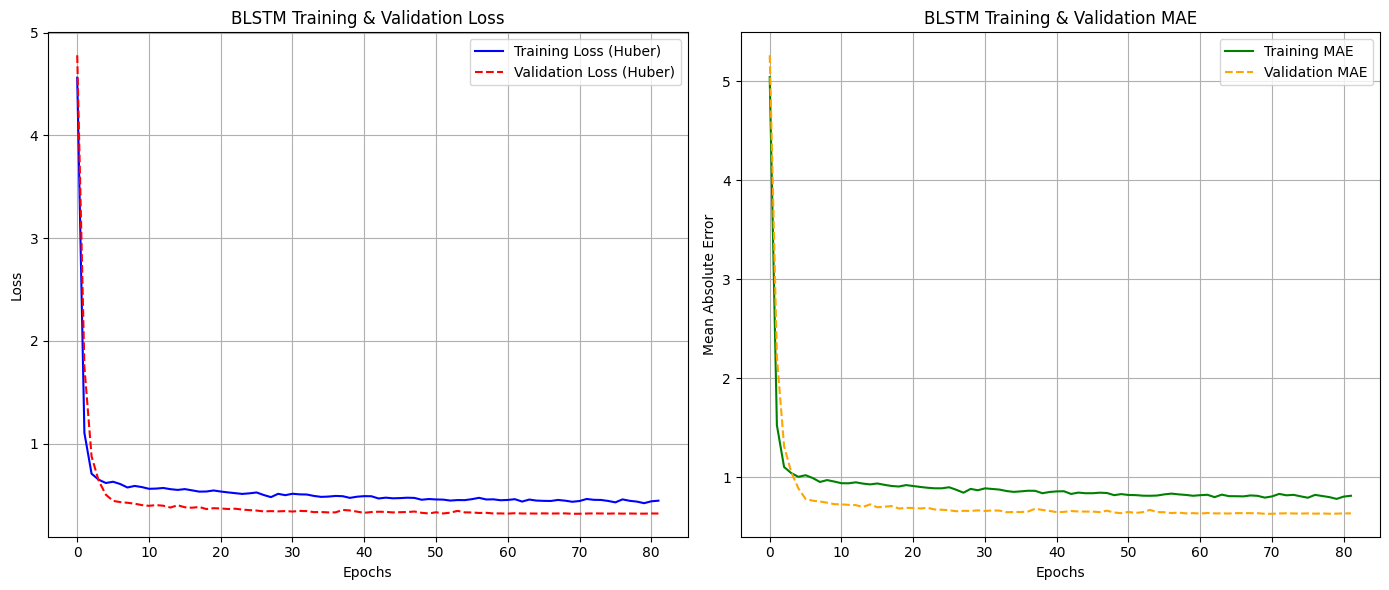


✅ Training Completed.
✅ Training History Plot saved as: ../Figures//blstm_training_performance.png


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 1, 128)         │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,853 (901.77 KB)

 Trainable params: 76,865 (300.25 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 153,732 (600.52 KB)

In [18]:
#-- Visualize Training History & Save to Figures Folder. --#
plt.figure(figsize=(14, 6))

#-- Subplot for Loss. --#
plt.subplot(1, 2, 1)
plt.plot(history_blstm.history['loss'], label='Training Loss (Huber)', color='blue')
plt.plot(history_blstm.history['val_loss'], label='Validation Loss (Huber)', color='red', linestyle='--')
plt.title('BLSTM Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

#-- Subplot for MAE. --#
plt.subplot(1, 2, 2)
plt.plot(history_blstm.history['mae'], label='Training MAE', color='green')
plt.plot(history_blstm.history['val_mae'], label='Validation MAE', color='orange', linestyle='--')
plt.title('BLSTM Training & Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

plt.tight_layout()

# --- CRITICAL: Saving to Figures folder ---
history_plot_path = f"{saved_folder}/blstm_training_performance.png"
plt.savefig(history_plot_path)
plt.show()

print(f"\n✅ Training Completed.")
print(f"✅ Training History Plot saved as: {history_plot_path}")
model_blstm.summary()

### Model Evaluation and Visualization ##

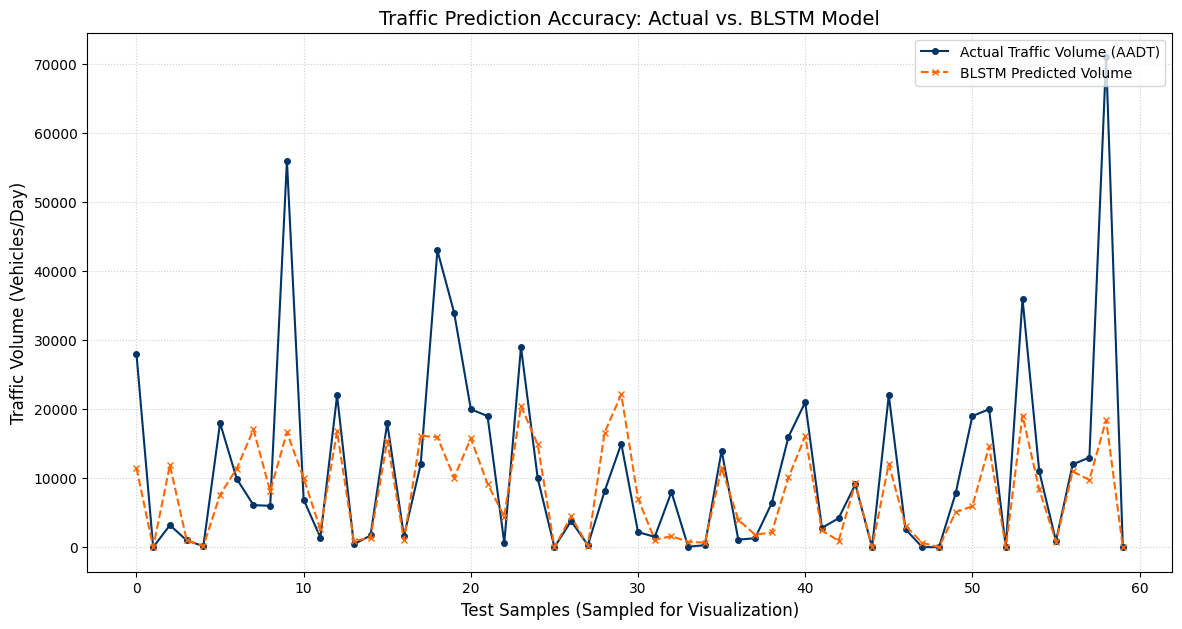

✅ Evaluation Phase Completed.
✅ Comparison Plot saved as: ../Figures//blstm_prediction_comparison.png
--- Performance Report ---
Mean Absolute Error (MAE): 4589.43 vehicles
R-squared Score (R2): 0.4163


In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

#-- Saved fodler. --#
folder_saved = '../Figures/'

#-- Performance Prediction. --#
y_pred_log = model_blstm.predict(X_test, verbose=0)

#-- Inverse Log Transformation. --#
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log).flatten()

#-- Visualization: Actual vs. Predicted Comparison. --#
plt.figure(figsize=(14, 7))

#-- Plotting the first 60 samples for a clear visual comparison. --#
sample_range = 60 
plt.plot(y_test_actual[:sample_range], label='Actual Traffic Volume (AADT)', color='#003366', marker='o', markersize=4, linewidth=1.5)
plt.plot(y_pred_actual[:sample_range], label='BLSTM Predicted Volume', color='#ff6600', linestyle='--', marker='x', markersize=5, linewidth=1.5)

plt.title('Traffic Prediction Accuracy: Actual vs. BLSTM Model', fontsize=14)
plt.xlabel('Test Samples (Sampled for Visualization)', fontsize=12)
plt.ylabel('Traffic Volume (Vehicles/Day)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

#-- Save the Evaluation Plot to the Figures folder
eval_plot_name = f"{folder_saved}/blstm_prediction_comparison.png"
plt.savefig(eval_plot_name, dpi=300) # High resolution for the report
plt.show()

#-- Final Performance Metrics for Documentation. --#
mae_score = mean_absolute_error(y_test_actual, y_pred_actual)
r2_val = r2_score(y_test_actual, y_pred_actual)

print(f"✅ Evaluation Phase Completed.")
print(f"✅ Comparison Plot saved as: {eval_plot_name}")
print(f"--- Performance Report ---")
print(f"Mean Absolute Error (MAE): {mae_score:.2f} vehicles")
print(f"R-squared Score (R2): {r2_val:.4f}")

### Real-Time traffic Advisory System ###

In [23]:
import os
from datetime import datetime

In [24]:
def monitor_blstm_realtime(model, X_input, df_source):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    file_timestamp = datetime.now().strftime("%H%M%S")
    
    # 1. Prediction logic (Using model_blstm)
    preds_log = model.predict(X_input, verbose=0)
    preds_actual = np.expm1(preds_log).flatten()
    
    # 2. Data Mapping
    test_idx = df_source.index[-len(X_input):]
    results = df_source.loc[test_idx, ['road_name', 'efficiency_index']].copy()
    results['Predicted_AADT'] = preds_actual
    
    # 3. Advisory Logic
    def get_advice(row):
        eff = row['efficiency_index']
        limit = 60
        if eff < 0.8:
            return pd.Series(['CONGESTED', f"{limit*0.5:.0f} km/h", 'Heavy: Slow down'])
        elif 0.8 <= eff <= 1.2:
            return pd.Series(['STABLE', f"{limit*0.8:.0f} km/h", 'Normal: Steady flow'])
        else:
            return pd.Series(['CLEAR', f"{limit:.0f} km/h", 'Optimal: Maintain limit'])

    results[['Status', 'Suggested_Speed', 'Guidance']] = results.apply(get_advice, axis=1)
    
    # 4. Save Table Snapshot to Figures (No folder creation)
    display_df = results.head(10)
    plt.figure(figsize=(12, 5))
    plt.axis('off')
    table = plt.table(cellText=display_df.values, colLabels=display_df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    plt.title(f"Traffic Advisory Dashboard - {now}", pad=20, fontweight='bold')
    
    # Saving to your existing folder
    save_path = f"../Figures/live_dashboard_{file_timestamp}.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close()
    
    # 5. Console Dashboard Output
    print(f"\n[BLSTM LIVE UPDATE] Time: {now}")
    print(f"{'ROAD NAME':<30} | {'STATUS':<10} | {'SPEED':<10} | {'GUIDANCE'}")
    print("-" * 85)
    for _, r in display_df.iterrows():
        print(f"{str(r['road_name'])[:30]:<30} | {r['Status']:<10} | {r['Suggested_Speed']:<10} | {r['Guidance']}")
    print(f"--- Snapshot saved to Figures/{file_timestamp}.png ---")

In [ ]:
INTERVAL = 600 

print("🚀 BLSTM System Started. Monitoring every 10 minutes...")
print("Check your 'Figures' folder for new snapshots. Press Stop to exit.")

try:
    while True:
        # Ensure we use the exact model name from Step 4
        if 'model_blstm' in locals():
            monitor_blstm_realtime(model_blstm, X_test, df_clean)
        else:
            print("❌ Error: 'model_blstm' variable not found in memory.")
            break
            
        print(f"\n[WAITING] Next update in {INTERVAL/60} minutes...")
        time.sleep(INTERVAL)
        
except KeyboardInterrupt:
    print("\n[STOPPED] Monitoring system terminated.")

🚀 BLSTM System Started. Monitoring every 10 minutes...
Check your 'Figures' folder for new snapshots. Press Stop to exit.

[BLSTM LIVE UPDATE] Time: 2026-03-31 10:38:18
ROAD NAME                      | STATUS     | SPEED      | GUIDANCE
-------------------------------------------------------------------------------------
PATCHEWOLLOCK-SEA LAKE ROAD    | CLEAR      | 60 km/h    | Optimal: Maintain limit
PAYNESVILLE ROAD               | CLEAR      | 60 km/h    | Optimal: Maintain limit
PAYNESVILLE ROAD               | CLEAR      | 60 km/h    | Optimal: Maintain limit
PAYNESVILLE ROAD               | CLEAR      | 60 km/h    | Optimal: Maintain limit
PEARCEDALE PARADE              | CLEAR      | 60 km/h    | Optimal: Maintain limit
PEARCEDALE PARADE              | CLEAR      | 60 km/h    | Optimal: Maintain limit
PEARCEDALE PARADE              | STABLE     | 48 km/h    | Normal: Steady flow
PEEL STREET                    | CLEAR      | 60 km/h    | Optimal: Maintain limit
PEEL STREET      